<a href="https://colab.research.google.com/github/camilogomezos/ICTC_TimeSeries_ARMA/blob/main/Trabajo_econometr%C3%ADa_2_Poster.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox

In [38]:
# Leemos el archivo directamente desde GitHub
url = 'https://raw.githubusercontent.com/camilogomezos/ICTC_TimeSeries_ARMA/refs/heads/main/ICTC_Indices_abr2026.csv'
df = pd.read_csv(url, decimal=',')

if df['ICTC'].dtype == 'O':
    df['ICTC'] = df['ICTC'].str.replace('"', '').str.replace(',', '.').astype(float)

df['Fecha'] = pd.date_range(start='2016-01-01', periods=len(df), freq='MS')
df.set_index('Fecha', inplace=True)
serie = df['ICTC']

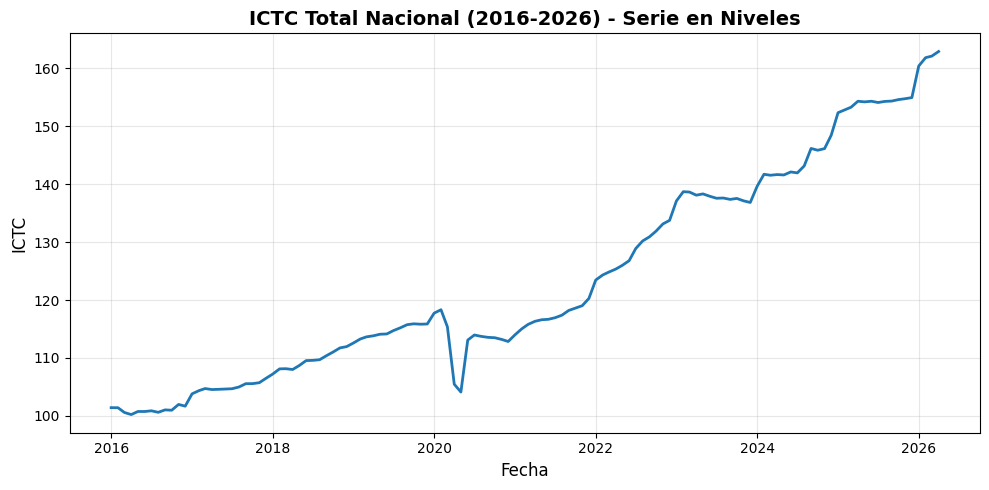

In [40]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=serie, color='#1f77b4', linewidth=2)
plt.title('ICTC Total Nacional (2016-2026) - Serie en Niveles', fontsize=14, fontweight='bold')
plt.ylabel('ICTC', fontsize=12)
plt.xlabel('Fecha', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('grafica_nivel.png')
plt.show()

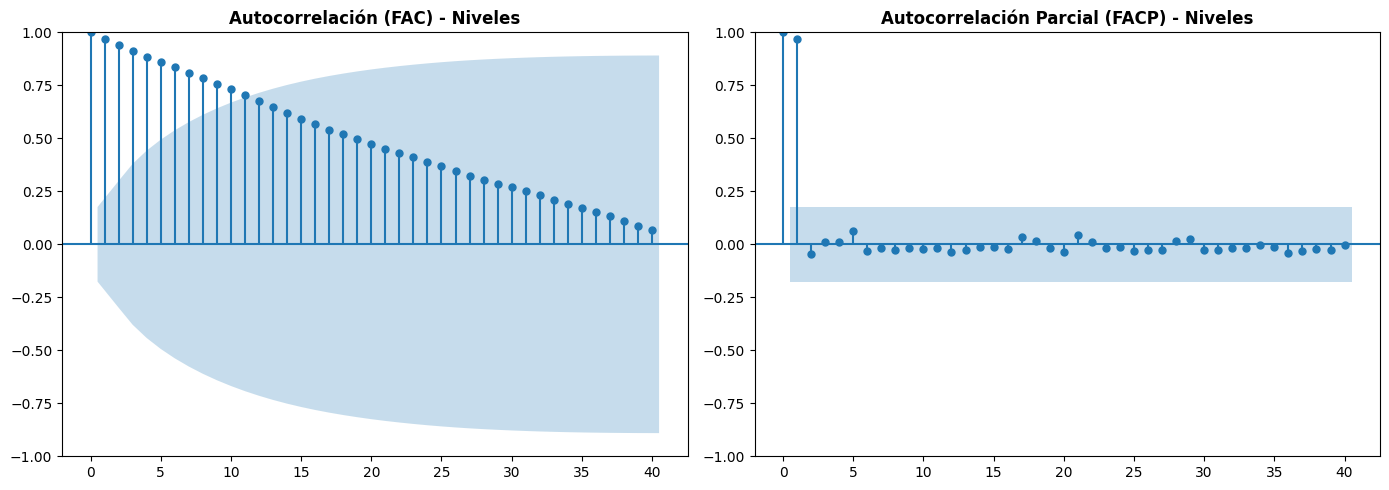

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(serie, ax=axes[0], lags=40, color='#1f77b4', alpha=0.05)
axes[0].set_title('Autocorrelación (FAC) - Niveles', fontweight='bold')
plot_pacf(serie, ax=axes[1], lags=40, color='#1f77b4', alpha=0.05)
axes[1].set_title('Autocorrelación Parcial (FACP) - Niveles', fontweight='bold')
plt.tight_layout()
plt.savefig('grafica_fac_facp.png')
plt.show()

In [42]:
adf_result = adfuller(serie.dropna())
print(f"--- Prueba Dickey-Fuller Aumentada (ADF) en Niveles ---")
print(f"Estadístico ADF: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")
print("Valores críticos:")
for key, value in adf_result[4].items():
    print(f"  {key}: {value:.4f}")
print(f"Número de observaciones usadas: {adf_result[3]}")

--- Prueba Dickey-Fuller Aumentada (ADF) en Niveles ---
Estadístico ADF: 1.6541
p-value: 0.9980
Valores críticos:
  1%: -3.4856
  5%: -2.8857
  10%: -2.5797
Número de observaciones usadas: 121


In [43]:
serie_log = np.log(serie)

serie_estacionaria = serie_log.diff().dropna()

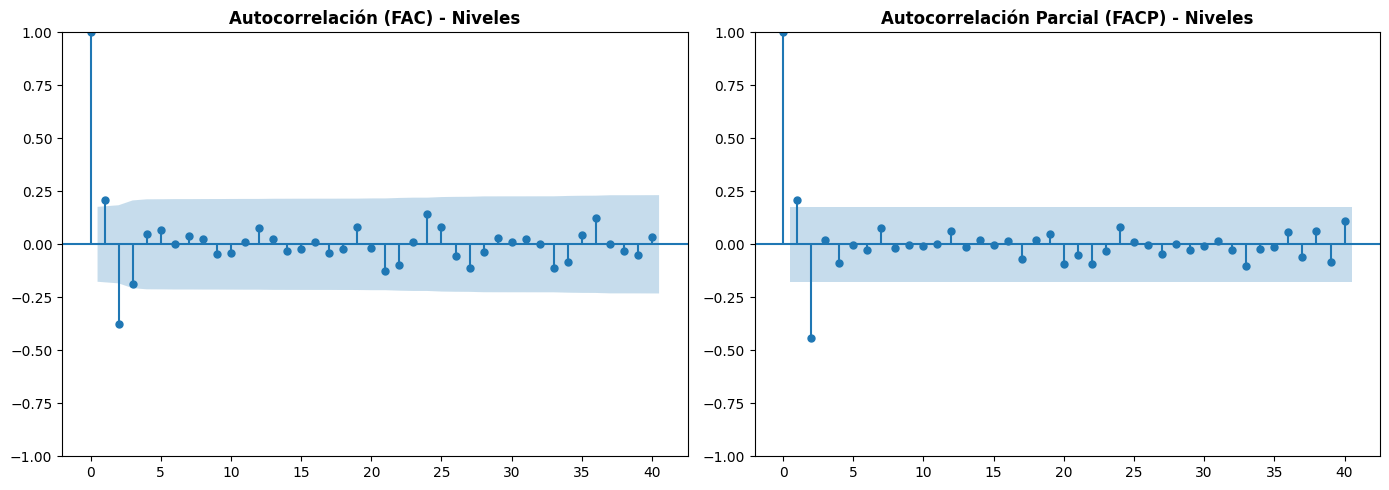

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_acf(serie_estacionaria, ax=axes[0], lags=40, color='#1f77b4', alpha=0.05)
axes[0].set_title('Autocorrelación (FAC) - Niveles', fontweight='bold')
plot_pacf(serie_estacionaria, ax=axes[1], lags=40, color='#1f77b4', alpha=0.05)
axes[1].set_title('Autocorrelación Parcial (FACP) - Niveles', fontweight='bold')
plt.tight_layout()
plt.savefig('graf_fac_facp_transformada.png')
plt.show()

In [46]:
resultados = []

for p in range(3):
    for q in range(3):
        try:
            # order=(p, d, q) -> d=1 porque sabemos que requiere una diferencia
            modelo = ARIMA(serie_log, order=(p, 1, q))
            ajuste = modelo.fit()
            resultados.append({
                'Modelo': f'ARIMA({p}, 1, {q})',
                'AIC': ajuste.aic,
                'BIC': ajuste.bic
            })
        except:
            continue

# Ordenar los resultados para encontrar el modelo más parsimonioso
df_resultados = pd.DataFrame(resultados).sort_values(by='BIC').reset_index(drop=True)
print(df_resultados)

           Modelo         AIC         BIC
0  ARIMA(2, 1, 0) -725.355097 -716.918544
1  ARIMA(0, 1, 1) -722.390286 -716.765918
2  ARIMA(0, 1, 2) -724.698899 -716.262346
3  ARIMA(1, 1, 1) -722.815741 -714.379187
4  ARIMA(2, 1, 1) -725.362506 -714.113768
5  ARIMA(1, 1, 2) -723.441446 -712.192708
6  ARIMA(2, 1, 2) -723.348653 -709.287731
7  ARIMA(1, 1, 0) -709.627634 -704.003265
8  ARIMA(0, 1, 0) -702.370510 -699.558326


In [47]:
modelo_final = ARIMA(serie_log, order=(2, 1, 0))
resultados_final = modelo_final.fit()
print(resultados_final.summary())

                               SARIMAX Results                                
Dep. Variable:                   ICTC   No. Observations:                  124
Model:                 ARIMA(2, 1, 0)   Log Likelihood                 365.678
Date:                Fri, 29 May 2026   AIC                           -725.355
Time:                        09:17:26   BIC                           -716.919
Sample:                    01-01-2016   HQIC                          -721.928
                         - 04-01-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3700      0.053      6.941      0.000       0.266       0.475
ar.L2         -0.3688      0.033    -11.263      0.000      -0.433      -0.305
sigma2         0.0002   8.32e-06     18.364      0.0

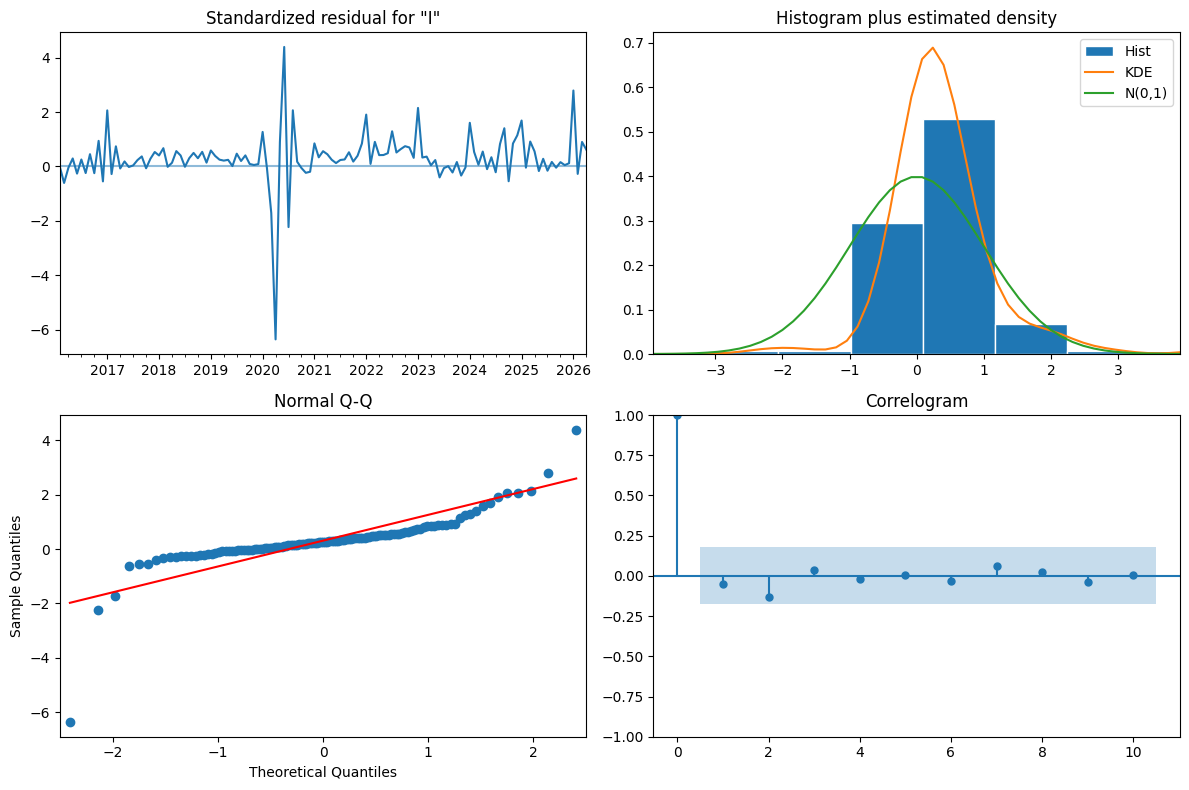

--- Prueba de Ljung-Box ---
     lb_stat  lb_pvalue
10  0.003084        1.0


In [48]:
# 1. Obtener residuos del modelo elegido
residuos = resultados_final.resid

# 2. Diagnóstico visual para el póster
resultados_final.plot_diagnostics(figsize=(12, 8))
plt.tight_layout()
plt.savefig('graf_fac_facp_transformada.png')
plt.show()

# 3. Prueba estadística de Ljung-Box
lb_test = acorr_ljungbox(residuos, lags=[10], return_df=True)
print("--- Prueba de Ljung-Box ---")
print(lb_test)

In [49]:
# Validación del supuesto de Media Cero
media_residuos = np.mean(residuos)
print(f"Media de los residuos: {media_residuos:.6f}")
if abs(media_residuos) < 0.05:
    print("-> ÉXITO: La media es estadísticamente cercana a cero.")
else:
    print("-> PELIGRO: La media está sesgada.")

Media de los residuos: 0.041064
-> ÉXITO: La media es estadísticamente cercana a cero.


In [50]:
# Validación del supuesto de Normalidad (Prueba Jarque-Bera)
jb_stat, jb_pvalue = stats.jarque_bera(residuos)
print(f"\n--- Prueba de Jarque-Bera (Normalidad) ---")
print(f"Estadístico JB: {jb_stat:.4f}")
print(f"p-value: {jb_pvalue:.4f}")


--- Prueba de Jarque-Bera (Normalidad) ---
Estadístico JB: 75429.3308
p-value: 0.0000
